<a href="https://colab.research.google.com/github/Ayabergh/sentiment-analysis/blob/main/Copie_de_SentimentAnalysisDataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd


In [ ]:
'''

splits = {'train': 'train_df.csv', 'validation': 'val_df.csv', 'test': 'test_df.csv'}
df = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])
'''

'\n\nsplits = {\'train\': \'train_df.csv\', \'validation\': \'val_df.csv\', \'test\': \'test_df.csv\'}\ndf = pd.read_csv("hf://datasets/Sp1786/multiclass-sentiment-analysis-dataset/" + splits["train"])\n'

In [ ]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "sentiment_data.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "abdelmalekeladjelet/sentiment-analysis-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_780/2490920701.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 22.8M/22.8M [00:00<00:00, 91.1MB/s]


First 5 records:    Unnamed: 0                                            Comment  Sentiment
0           0  lets forget apple pay required brand new iphon...          1
1           1  nz retailers don’t even contactless credit car...          0
2           2  forever acknowledge channel help lessons ideas...          2
3           3  whenever go place doesn’t take apple pay doesn...          0
4           4  apple pay convenient secure easy use used kore...          2


In [ ]:
n_per_class = 13333

df_40k = (
    df.groupby('Sentiment', group_keys=False)
      .apply(lambda x: x.sample(n=n_per_class, random_state=42))
      .reset_index(drop=True)
)

print(df_40k['Sentiment'].value_counts())

Sentiment
0    13333
1    13333
2    13333
Name: count, dtype: int64


/tmp/ipykernel_780/113890937.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(n=n_per_class, random_state=42))


In [ ]:
df=df_40k

In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment
0,50826,safeway bathroom still smells like ass,0
1,8005,calling someone “racist” “phobic” evidence bac...,0
2,10308,roast anybody without making feel bad,0
3,144702,plz send shah pakistan modi destroy economy th...,0
4,109841,recent survey teamlease services showed millio...,0


In [ ]:
df['Sentiment'].unique()

array([0, 1, 2])

In [ ]:
df.shape

(39999, 3)

In [ ]:
df.describe()

,Unnamed: 0,Sentiment
count,39999.000000,39999.000000
mean,120741.635391,1.000000
std,69340.596586,0.816507
min,31.000000,0.000000
25%,60721.500000,0.000000
50%,119917.000000,1.000000
75%,180724.000000,2.000000
max,241916.000000,2.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39999 entries, 0 to 39998
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  39999 non-null  int64 
 1   Comment     39969 non-null  object
 2   Sentiment   39999 non-null  int64 
dtypes: int64(2), object(1)
memory usage: 937.6+ KB


### Exploration Data Analysis

In [ ]:
df.isna().sum()

,0
Unnamed: 0,0
Comment,30
Sentiment,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)

empty texts

In [ ]:
(df['Comment'].str.strip()=='').sum()

np.int64(0)

text length

In [ ]:
df['text_len'] = df['Comment'].str.len()
df['text_len'].describe()

,text_len
count,39969.000000
mean,87.912933
std,75.598427
min,1.000000
25%,41.000000
50%,72.000000
75%,124.000000
max,5080.000000


In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment,text_len
0,50826,safeway bathroom still smells like ass,0,38
1,8005,calling someone “racist” “phobic” evidence bac...,0,68
2,10308,roast anybody without making feel bad,0,37
3,144702,plz send shah pakistan modi destroy economy th...,0,156
4,109841,recent survey teamlease services showed millio...,0,168


text len distribution

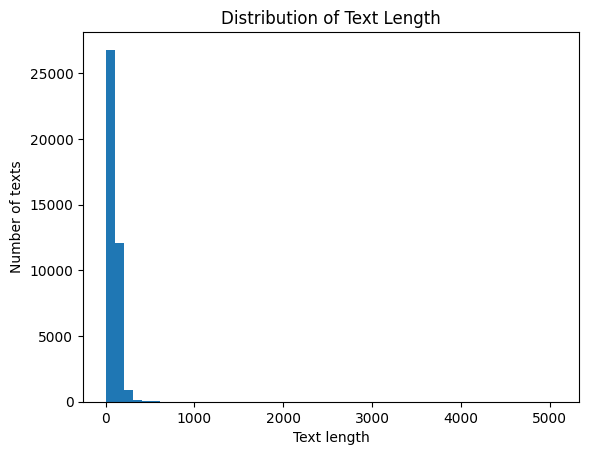

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['text_len'], bins=50)
plt.xlabel('Text length')
plt.ylabel('Number of texts')
plt.title('Distribution of Text Length')
plt.show()

short text

In [ ]:
short_text = df[df['text_len']<=3]

In [ ]:
print(short_text[['Comment', 'Sentiment']])
short_text.shape

      Comment  Sentiment
545       fun          0
665       day          0
3718      fan          0
5000      wtf          0
7790      yep          0
8489       oh          0
9326      sad          0
10220     sad          0
12436     bad          0
13578     may          1
13636     ari          1
13803       u          1
14001     way          1
14720     bjp          1
16168     yes          1
17877     sad          1
17920      ok          1
18613     say          1
18696     hes          1
19473     cat          1
19672      im          1
19757     new          1
19874     see          1
20002     len          1
20346     yes          1
20930     app          1
21353     yep          1
21433     thx          1
21661     ohh          1
22076     see          1
23563     saw          1
23628     see          1
23632     rus          1
24018     yes          1
24307     hey          1
25183      im          1
26589     ive          1
26667       💖          2
27714     yes          2


(45, 4)

In [ ]:
meaningless_words = [
    'hi', 'hello', 'hey',
    'ok', 'okay',
    'yes', 'yeah',
    'thanks', 'thank',
    'lol',
    'pay','yy','nyc','yas','Gud  ','try','wew','♡♡','Baf',
    'ME','Oke  '
]
df = df[
    ~df['Comment'].str.lower().str.strip().isin(meaningless_words)
].copy()


In [ ]:
import re

def clean_text(text):
    if not isinstance(text, str):
        return ""

    # Garder lettres, chiffres et espaces
    text = re.sub(r'[^a-zA-ZÀ-ÿ0-9\s]', ' ', text)

    # Supprimer les espaces multiples
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['text_clean'] = df['Comment'].apply(clean_text)

In [ ]:
import emoji

def detect_emojis(text):
    return [char for char in text if char in emoji.EMOJI_DATA]

# Example usage
df['emojis'] = df['Comment'].apply(detect_emojis)
print("\nEmojis detected:", df['emojis'].tolist())


Emojis detected: [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [

In [ ]:
def remove_emojis(text):
    return ''.join(char for char in text if char not in emoji.EMOJI_DATA)

df['Comment'] = df['Comment'].apply(remove_emojis)


In [ ]:
threshold = df['text_len'].quantile(0.99)
print('threshold:',threshold)
long_text = df[df['text_len']>threshold]
print(long_text[['Comment', 'Sentiment']])
long_text.shape

threshold: 263.0
                                                 Comment  Sentiment
99     concept good execution lacks constant issues s...          0
216    use mase sunday school teacher atlanta first g...          0
359    syncing doesnt work whole point upgrading pro ...          0
368    loved app recently realized dont use half much...          0
465    parents expect us school constant straight a’s...          0
...                                                  ...        ...
39258  business owner video enthusiast love channel d...          2
39321  computer science major soon working nyc softwa...          2
39419  got hyped especially hrithik highlight also fa...          2
39703  hey everyone wanted make video could easily te...          2
39798  havent come across better app type project man...          2

[397 rows x 2 columns]


(397, 6)

In [ ]:
df['Sentiment'].value_counts()

,count
Sentiment,
0,13330
2,13316
1,13295


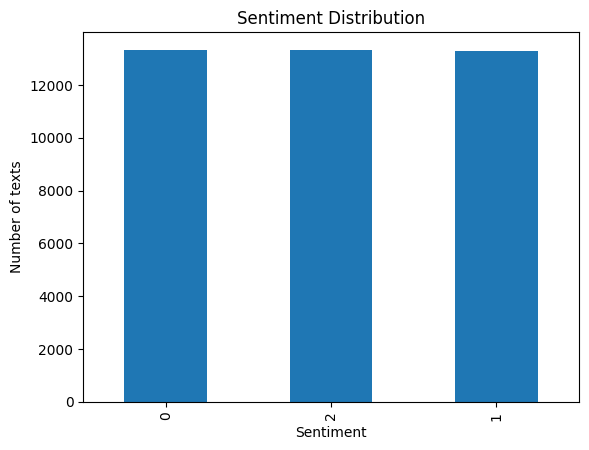

In [ ]:
df['Sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel('Number of texts')
plt.title('Sentiment Distribution')
plt.show()

In [ ]:
html_count=df['Comment'].str.contains(
      r'<[^>]+>',
    regex=True,
    na=False
).sum()
print("Texts containing HTML:", html_count)

Texts containing HTML: 0


In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'<[^>]+>',
    '',
    regex=True
)

In [ ]:
url_count = df['Comment'].str.contains(
    r'https?://\S+|www\.\S+',
    regex=True,
    na=False
).sum()

print("Comments containing URLs:", url_count)

Comments containing URLs: 0


In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'https?://\S+|www\.\S+',
    '',
    regex=True
)

In [ ]:
df['Comment']=df['Comment'].str.replace(
    r'\s+',
    ' ',
    regex=True
)

In [ ]:
'''
import re

df['punctuation_count']= df['Comment'].apply(
    lambda x:len(re.findall(r'[!?.,;:]',x)))
'''

"\nimport re\n\ndf['punctuation_count']= df['Comment'].apply(\n    lambda x:len(re.findall(r'[!?.,;:]',x)))\n"

In [ ]:
df['Comment'].iloc[2]

'roast anybody without making feel bad'

In [ ]:
df.head()

,Unnamed: 0,Comment,Sentiment,text_len,text_clean,emojis
0,50826,safeway bathroom still smells like ass,0,38,safeway bathroom still smells like ass,[]
1,8005,calling someone “racist” “phobic” evidence bac...,0,68,calling someone racist phobic evidence back sh...,[]
2,10308,roast anybody without making feel bad,0,37,roast anybody without making feel bad,[]
3,144702,plz send shah pakistan modi destroy economy th...,0,156,plz send shah pakistan modi destroy economy th...,[]
4,109841,recent survey teamlease services showed millio...,0,168,recent survey teamlease services showed millio...,[]


check emojis

In [ ]:
emojy_pattern = r'[^\x00-\x7f]'

emoji_texts = df[df['Comment'].str.contains(
    emojy_pattern,
    regex=True,
    na=False
)]
print(emoji_texts[['Comment', 'Sentiment']].head(20))
emoji_texts.shape

                                               Comment  Sentiment
1    calling someone “racist” “phobic” evidence bac...          0
4    recent survey teamlease services showed millio...          0
6    modiâ promise bring internet rural india fai...          0
14   want comment fake never issued signed statemen...          0
32   believe live modi hate minorities pluralism in...          0
33   destroying satellites mediaâ freedom express...          0
35   donâ serious talk rahul also get list top in...          0
47   even modi doesnâ win according stats italian...          0
52   âdelaying decisions criminal negligenceâ m...          0
56   donâ understand people afraid chest thumping...          0
63   would taken blame mission failure internationa...          0
65   india shoots satellite space modi salutes majo...          0
74   sheâ corrupt means modi sarkar fails take le...          0
83   nirav modi vijay mallya share jail cell mumbai...          0
95   lot t

(3920, 6)

#### tokenization

In [ ]:
import nltk
from nltk.tokenize import word_tokenize

In [ ]:
nltk.download('punkt')
nltk.download('punkt_tab')

df['tokens'] = df['Comment'].apply(word_tokenize)
print(df[['Comment', 'tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                                             Comment  \
0             safeway bathroom still smells like ass   
1  calling someone “racist” “phobic” evidence bac...   
2              roast anybody without making feel bad   
3  plz send shah pakistan modi destroy economy th...   
4  recent survey teamlease services showed millio...   

                                              tokens  
0      [safeway, bathroom, still, smells, like, ass]  
1  [calling, someone, “, racist, ”, “, phobic, ”,...  
2       [roast, anybody, without, making, feel, bad]  
3  [plz, send, shah, pakistan, modi, destroy, eco...  
4  [recent, survey, teamlease, services, showed, ...  


In [ ]:
print(df['tokens'].iloc[0])

['safeway', 'bathroom', 'still', 'smells', 'like', 'ass']


In [ ]:
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words =set(stopwords.words('english'))
negation_words = {'no', 'not', 'never', 'nor'}
stop_words = stop_words - negation_words
list(stop_words)[:20]

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


['on',
 "she's",
 "we'll",
 'when',
 "you're",
 'had',
 "isn't",
 'my',
 'couldn',
 'more',
 'who',
 'or',
 'about',
 'won',
 'but',
 'm',
 'haven',
 've',
 "we're",
 'very']

In [ ]:
df['tokens'] = df['Comment'].apply(word_tokenize)

In [ ]:
df['tokens'] = df['tokens'].apply(
    lambda tokens: [word for word in tokens if word.lower() not in stop_words]
)

In [ ]:
print(df[['Comment', 'tokens']].head())

                                             Comment  \
0             safeway bathroom still smells like ass   
1  calling someone “racist” “phobic” evidence bac...   
2              roast anybody without making feel bad   
3  plz send shah pakistan modi destroy economy th...   
4  recent survey teamlease services showed millio...   

                                              tokens  
0      [safeway, bathroom, still, smells, like, ass]  
1  [calling, someone, “, racist, ”, “, phobic, ”,...  
2       [roast, anybody, without, making, feel, bad]  
3  [plz, send, shah, pakistan, modi, destroy, eco...  
4  [recent, survey, teamlease, services, showed, ...  


### Stemming

In [ ]:
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()
df['tokens'] = df['tokens'].apply(
    lambda tokens: [stemmer.stem(word) for word in tokens]
)

In [ ]:
print(df[['Comment', 'tokens']].head())

                                             Comment  \
0             safeway bathroom still smells like ass   
1  calling someone “racist” “phobic” evidence bac...   
2              roast anybody without making feel bad   
3  plz send shah pakistan modi destroy economy th...   
4  recent survey teamlease services showed millio...   

                                              tokens  
0       [safeway, bathroom, still, smell, like, ass]  
1  [call, someon, “, racist, ”, “, phobic, ”, evi...  
2         [roast, anybodi, without, make, feel, bad]  
3  [plz, send, shah, pakistan, modi, destroy, eco...  
4  [recent, survey, teamleas, servic, show, milli...  


### Lemmatization

In [ ]:
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

df['tokens'] = df['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


In [ ]:
print(df[['Comment','tokens']].head())

                                             Comment  \
0             safeway bathroom still smells like ass   
1  calling someone “racist” “phobic” evidence bac...   
2              roast anybody without making feel bad   
3  plz send shah pakistan modi destroy economy th...   
4  recent survey teamlease services showed millio...   

                                              tokens  
0        [safeway, bathroom, still, smell, like, as]  
1  [call, someon, “, racist, ”, “, phobic, ”, evi...  
2         [roast, anybodi, without, make, feel, bad]  
3  [plz, send, shah, pakistan, modi, destroy, eco...  
4  [recent, survey, teamleas, servic, show, milli...  


### converting into numerical features

In [ ]:
from sklearn.model_selection import train_test_split

X= df['Comment']
y= df['Sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


TF-IDF

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [ ]:
print(X_train_tfidf.shape)

(31952, 44442)


In [ ]:
print(X_train_tfidf[50].toarray())

[[0. 0. 0. ... 0. 0. 0.]]


In [ ]:
print(tfidf.get_feature_names_out()[:-20000])

['aaa' 'aaaa' 'aaaaa' ... 'militancy' 'militant' 'militants']


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred = model.predict(X_test_tfidf)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.76      0.72      0.74      2666
           1       0.70      0.77      0.73      2659
           2       0.78      0.74      0.76      2664

    accuracy                           0.74      7989
   macro avg       0.74      0.74      0.74      7989
weighted avg       0.74      0.74      0.74      7989

